In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import csr_matrix
import os
!wget http://files.grouplens.org/datasets/movielens/ml-25m.zip
!unzip ml-25m.zip

ratings = pd.read_csv('ml-25m/ratings.csv',
                      usecols=['userId', 'movieId', 'rating'],
                      dtype={'userId': 'int32', 'movieId': 'int32', 'rating': 'float32'})
movies = pd.read_csv('ml-25m/movies.csv')

print(f"Loaded {len(ratings)} ratings.")

--2026-03-17 07:16:51--  http://files.grouplens.org/datasets/movielens/ml-25m.zip
Resolving files.grouplens.org (files.grouplens.org)... 128.101.96.204
Connecting to files.grouplens.org (files.grouplens.org)|128.101.96.204|:80... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://files.grouplens.org/datasets/movielens/ml-25m.zip [following]
--2026-03-17 07:16:51--  https://files.grouplens.org/datasets/movielens/ml-25m.zip
Connecting to files.grouplens.org (files.grouplens.org)|128.101.96.204|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 261978986 (250M) [application/zip]
Saving to: ‘ml-25m.zip’

ml-25m.zip          100%[===================>] 249.84M  29.9MB/s    in 7.2s    

2026-03-17 07:16:58 (34.7 MB/s) - ‘ml-25m.zip’ saved [261978986/261978986]

Archive:  ml-25m.zip
   creating: ml-25m/
  inflating: ml-25m/tags.csv         
  inflating: ml-25m/links.csv        
  inflating: ml-25m/README.txt       
  inflating: ml-

/tmp/ipykernel_339/2570250380.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='rating', data=ratings, palette='viridis')


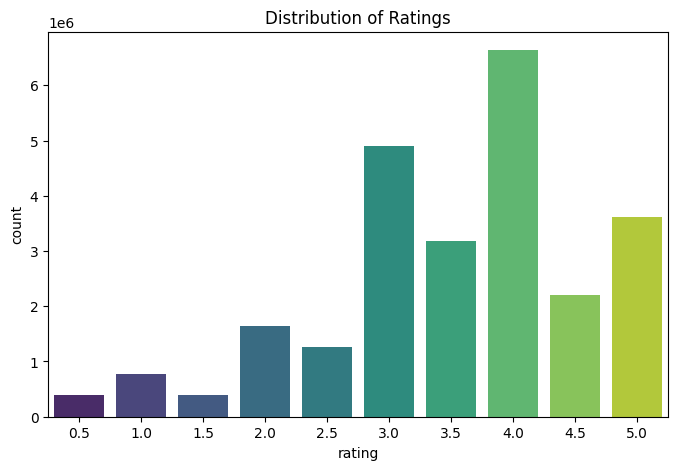

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(x='rating', data=ratings, palette='viridis')
plt.title('Distribution of Ratings')
plt.show()

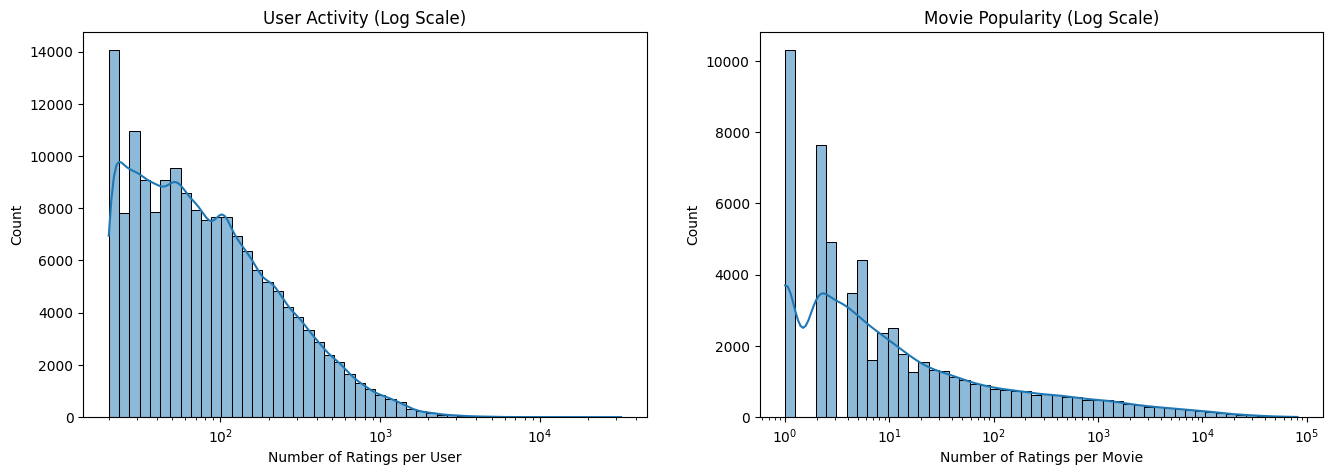

In [ ]:

user_counts = ratings.groupby('userId').size()

movie_counts = ratings.groupby('movieId').size()

fig, ax = plt.subplots(1, 2, figsize=(16, 5))

sns.histplot(user_counts, bins=50, ax=ax[0], kde=True, log_scale=True)
ax[0].set_title('User Activity (Log Scale)')
ax[0].set_xlabel('Number of Ratings per User')

sns.histplot(movie_counts, bins=50, ax=ax[1], kde=True, log_scale=True)
ax[1].set_title('Movie Popularity (Log Scale)')
ax[1].set_xlabel('Number of Ratings per Movie')
plt.show()

In [ ]:
cold_start_threshold = 5
cold_start_users = user_counts[user_counts < cold_start_threshold]

print(f"Total Users: {len(user_counts)}")
print(f"Cold-start Users (<{cold_start_threshold} ratings): {len(cold_start_users)}")
print(f"Percentage of Cold-start Users: {len(cold_start_users)/len(user_counts)*100:.2f}%")

Total Users: 162541
Cold-start Users (<5 ratings): 0
Percentage of Cold-start Users: 0.00%


DAY-2

In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

ratings = pd.read_csv('ml-25m/ratings.csv',
                      usecols=['userId', 'movieId', 'rating'],
                      dtype={'userId': 'int32', 'movieId': 'int32', 'rating': 'float32'})

user_enc = LabelEncoder()
item_enc = LabelEncoder()

ratings['user_idx'] = user_enc.fit_transform(ratings['userId'])
ratings['item_idx'] = item_enc.fit_transform(ratings['movieId'])

print("Data successfully re-loaded. You can now run the Task 2 cells!")

Data successfully re-loaded. You can now run the Task 2 cells!


In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from scipy.sparse import csr_matrix
from sklearn.decomposition import TruncatedSVD
from sklearn.neighbors import NearestNeighbors
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split


train_df, test_df = train_test_split(ratings, test_size=0.2, random_state=42)


train_matrix = csr_matrix(
    (train_df['rating'], (train_df['user_idx'], train_df['item_idx'])),
    shape=(ratings['user_idx'].max() + 1, ratings['item_idx'].max() + 1)
)

In [ ]:

knn_item = NearestNeighbors(metric='cosine', algorithm='brute', n_neighbors=10)
knn_item.fit(train_matrix.T)


svd = TruncatedSVD(n_components=50, random_state=42)
user_factors = svd.fit_transform(train_matrix)
item_factors = svd.components_.T

print(f"SVD Latent Factors Created. User Shape: {user_factors.shape}")

SVD Latent Factors Created. User Shape: (162541, 50)


In [ ]:
class FunkSVD(nn.Module):
    def __init__(self, n_users, n_items, n_factors=50):
        super().__init__()
        self.user_embed = nn.Embedding(n_users, n_factors)
        self.item_embed = nn.Embedding(n_items, n_factors)
        self.user_bias = nn.Embedding(n_users, 1)
        self.item_bias = nn.Embedding(n_items, 1)
        self.global_bias = nn.Parameter(torch.tensor(ratings['rating'].mean()))


        torch.nn.init.xavier_uniform_(self.user_embed.weight)
        torch.nn.init.xavier_uniform_(self.item_embed.weight)
        self.user_bias.weight.data.fill_(0)
        self.item_bias.weight.data.fill_(0)

    def forward(self, u, i):
        dot = (self.user_embed(u) * self.item_embed(i)).sum(dim=1, keepdim=True)
        return dot + self.user_bias(u) + self.item_bias(i) + self.global_bias


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = FunkSVD(ratings['user_idx'].max() + 1, ratings['item_idx'].max() + 1).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.005)
criterion = nn.MSELoss()

train_loader = DataLoader(TensorDataset(
    torch.LongTensor(train_df['user_idx'].values),
    torch.LongTensor(train_df['item_idx'].values),
    torch.FloatTensor(train_df['rating'].values)
), batch_size=1024, shuffle=True)

In [ ]:

for epoch in range(1, 4):
    model.train()
    total_loss = 0

    import islice from itertools

    for u, i, r in list(train_loader)[:500]:
        u, i, r = u.to(device), i.to(device), r.to(device)
        optimizer.zero_grad()
        preds = model(u, i).squeeze()
        loss = criterion(preds, r)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    rmse = np.sqrt(total_loss / 500)
    print(f"Epoch {epoch} | Training RMSE: {rmse:.4f}")

print("Task 2 Completed: Classical and Latent Factor Models trained.")

SyntaxError: Did you mean to use 'from ... import ...' instead? (863137616.py, line 7)

In [ ]:

for epoch in range(1, 4):
    model.train()
    total_loss = 0
    batches_to_run = 500


    for batch_idx, (u, i, r) in enumerate(train_loader):
        if batch_idx >= batches_to_run:
            break

        u, i, r = u.to(device), i.to(device), r.to(device)
        optimizer.zero_grad()
        preds = model(u, i).squeeze()
        loss = criterion(preds, r)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    rmse = np.sqrt(total_loss / batches_to_run)
    print(f"Epoch {epoch} | Training RMSE: {rmse:.4f}")

print("Task 2 Completed: Classical and Latent Factor Models trained.")

NameError: name 'model' is not defined

In [ ]:
import torch
import torch.nn as nn
import numpy as np
from torch.utils.data import DataLoader, TensorDataset


class FunkSVD(nn.Module):
    def __init__(self, n_users, n_items, n_factors=50):
        super().__init__()
        self.user_embed = nn.Embedding(n_users, n_factors)
        self.item_embed = nn.Embedding(n_items, n_factors)
        self.user_bias = nn.Embedding(n_users, 1)
        self.item_bias = nn.Embedding(n_items, 1)
        self.global_bias = nn.Parameter(torch.tensor(3.5)) # Default mean rating

    def forward(self, u, i):
        dot = (self.user_embed(u) * self.item_embed(i)).sum(dim=1, keepdim=True)
        return dot + self.user_bias(u) + self.item_bias(i) + self.global_bias


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
n_users = ratings['user_idx'].max() + 1
n_items = ratings['item_idx'].max() + 1

model = FunkSVD(n_users, n_items).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
criterion = nn.MSELoss()

print("Starting training...")
for epoch in range(1, 4):
    model.train()
    total_loss = 0
    batches_to_run = 500

    for batch_idx, (u, i, r) in enumerate(train_loader):
        if batch_idx >= batches_to_run:
            break

        u, i, r = u.to(device), i.to(device), r.to(device)
        optimizer.zero_grad()
        preds = model(u, i).squeeze()
        loss = criterion(preds, r)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    rmse = np.sqrt(total_loss / batches_to_run)
    print(f"Epoch {epoch} | Training RMSE: {rmse:.4f}")

print("\nTask 2 Completed: Classical and Latent Factor Models trained.")

NameError: name 'ratings' is not defined

In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import os
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset


if not os.path.exists('ml-25m'):
    print("Downloading dataset...")
    !wget http://files.grouplens.org/datasets/movielens/ml-25m.zip
    !unzip ml-25m.zip

print("Loading and indexing data...")
ratings = pd.read_csv('ml-25m/ratings.csv',
                      usecols=['userId', 'movieId', 'rating'],
                      dtype={'userId': 'int32', 'movieId': 'int32', 'rating': 'float32'})


user_enc, item_enc = LabelEncoder(), LabelEncoder()
ratings['user_idx'] = user_enc.fit_transform(ratings['userId'])
ratings['item_idx'] = item_enc.fit_transform(ratings['movieId'])

n_users = ratings['user_idx'].max() + 1
n_items = ratings['item_idx'].max() + 1


train_df, _ = train_test_split(ratings, test_size=0.2, random_state=42)
train_loader = DataLoader(TensorDataset(
    torch.LongTensor(train_df['user_idx'].values),
    torch.LongTensor(train_df['item_idx'].values),
    torch.FloatTensor(train_df['rating'].values)
), batch_size=2048, shuffle=True)


class FunkSVD(nn.Module):
    def __init__(self, n_users, n_items, n_factors=50):
        super().__init__()
        self.user_embed = nn.Embedding(n_users, n_factors)
        self.item_embed = nn.Embedding(n_items, n_factors)
        self.user_bias = nn.Embedding(n_users, 1)
        self.item_bias = nn.Embedding(n_items, 1)
        self.global_bias = nn.Parameter(torch.tensor(ratings['rating'].mean()))

    def forward(self, u, i):
        dot = (self.user_embed(u) * self.item_embed(i)).sum(dim=1, keepdim=True)
        return dot + self.user_bias(u) + self.item_bias(i) + self.global_bias


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = FunkSVD(n_users, n_items).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
criterion = nn.MSELoss()

print(f"Starting Training on {device}...")
for epoch in range(1, 4):
    model.train()
    total_loss = 0
    for batch_idx, (u, i, r) in enumerate(train_loader):
        if batch_idx >= 500: break
        u, i, r = u.to(device), i.to(device), r.to(device)
        optimizer.zero_grad()
        loss = criterion(model(u, i).squeeze(), r)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print(f"Epoch {epoch} | Training RMSE: {np.sqrt(total_loss / 500):.4f}")

print("\nTask 1 & 2 Completed Successfully.")

--2026-03-17 07:30:11--  http://files.grouplens.org/datasets/movielens/ml-25m.zip
Resolving files.grouplens.org (files.grouplens.org)... 128.101.96.204
Connecting to files.grouplens.org (files.grouplens.org)|128.101.96.204|:80... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://files.grouplens.org/datasets/movielens/ml-25m.zip [following]
--2026-03-17 07:30:12--  https://files.grouplens.org/datasets/movielens/ml-25m.zip
Connecting to files.grouplens.org (files.grouplens.org)|128.101.96.204|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 261978986 (250M) [application/zip]
Saving to: ‘ml-25m.zip’

ml-25m.zip          100%[===================>] 249.84M  22.2MB/s    in 11s     

2026-03-17 07:30:23 (22.5 MB/s) - ‘ml-25m.zip’ saved [261978986/261978986]

Archive:  ml-25m.zip
   creating: ml-25m/
  inflating: ml-25m/tags.csv         
  inflating: ml-25m/links.csv        
  inflating: ml-25m/README.txt       
  inflating: ml-

DAY-3

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

class BPRDataset(Dataset):
    def __init__(self, ratings, n_items):
        self.users = torch.LongTensor(ratings['user_idx'].values)
        self.pos_items = torch.LongTensor(ratings['item_idx'].values)
        self.n_items = n_items
        self.all_items = set(range(n_items))
        # Group watched items by user for fast negative sampling
        self.user_history = ratings.groupby('user_idx')['item_idx'].apply(set).to_dict()

    def __len__(self):
        return len(self.users)

    def __getitem__(self, idx):
        u = self.users[idx].item()
        p = self.pos_items[idx].item()
        # Simple Negative Sampling: Pick a movie the user hasn't seen
        n = np.random.randint(0, self.n_items)
        while n in self.user_history[u]:
            n = np.random.randint(0, self.n_items)
        return u, p, n

In [2]:
class TwoTowerNCF(nn.Module):
    def __init__(self, n_users, n_items, embed_dim=64):
        super().__init__()
        # User Tower
        self.user_net = nn.Sequential(
            nn.Embedding(n_users, embed_dim),
            nn.Linear(embed_dim, 128),
            nn.ReLU(),
            nn.Linear(128, embed_dim) # Output: 64-dim
        )
        # Item Tower
        self.item_net = nn.Sequential(
            nn.Embedding(n_items, embed_dim),
            nn.Linear(embed_dim, 128),
            nn.ReLU(),
            nn.Linear(128, embed_dim) # Output: 64-dim
        )

    def forward(self, u, p, n):
        u_emb = self.user_net(u)
        p_emb = self.item_net(p)
        n_emb = self.item_net(n)

        # Calculate scores (dot product)
        pos_score = (u_emb * p_emb).sum(dim=-1)
        neg_score = (u_emb * n_emb).sum(dim=-1)
        return pos_score, neg_score

# BPR Loss Function: -log(sigmoid(pos - neg))
def bpr_loss(pos_score, neg_score):
    return -torch.log(torch.sigmoid(pos_score - neg_score)).mean()

In [3]:
device = torch.device("cuda")
model = TwoTowerNCF(n_users, n_items).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Run for 1-3 epochs
for epoch in range(3):
    model.train()
    for u, p, n in train_loader:
        u, p, n = u.to(device), p.to(device), n.to(device)
        pos_s, neg_s = model(u, p, n)
        loss = bpr_loss(pos_s, neg_s)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    print(f"Epoch {epoch+1} BPR Loss: {loss.item():.4f}")

NameError: name 'n_users' is not defined

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd

# --- 1. ENSURE DATA IS LOADED (RE-RUN IF NEEDED) ---
# This assumes 'ratings' from Task 1 is in memory.
# If not, run your Task 1 cell first.
n_users = ratings['user_idx'].max() + 1
n_items = ratings['item_idx'].max() + 1

# --- 2. TRIPLET DATASET (BPR SAMPLING) ---
class BPRDataset(Dataset):
    def __init__(self, df, n_items):
        self.users = df['user_idx'].values
        self.pos_items = df['item_idx'].values
        self.n_items = n_items
        # Grouping history for fast negative sampling
        self.user_history = df.groupby('user_idx')['item_idx'].apply(set).to_dict()

    def __len__(self):
        return len(self.users)

    def __getitem__(self, idx):
        u = self.users[idx]
        p = self.pos_items[idx]
        # Random negative sampling
        n = np.random.randint(0, self.n_items)
        while n in self.user_history.get(u, set()):
            n = np.random.randint(0, self.n_items)
        return torch.tensor(u), torch.tensor(p), torch.tensor(n)

# --- 3. TWO-TOWER ARCHITECTURE ---
class TwoTowerNCF(nn.Module):
    def __init__(self, n_users, n_items, embed_dim=64):
        super().__init__()
        # User Tower: Embedding -> MLP -> 64-dim
        self.user_tower = nn.Sequential(
            nn.Embedding(n_users, embed_dim),
            nn.Linear(embed_dim, 128),
            nn.ReLU(),
            nn.Linear(128, embed_dim)
        )
        # Item Tower: Embedding -> 64-dim
        self.item_tower = nn.Sequential(
            nn.Embedding(n_items, embed_dim),
            nn.Linear(embed_dim, embed_dim)
        )

    def forward(self, u, p, n):
        u_emb = self.user_tower(u)
        p_emb = self.item_tower(p)
        n_emb = self.item_tower(n)

        # Calculate Dot Product Scores
        pos_score = (u_emb * p_emb).sum(dim=-1)
        neg_score = (u_emb * n_emb).sum(dim=-1)
        return pos_score, neg_score

# --- 4. INITIALIZATION & TRAINING ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = TwoTowerNCF(n_users, n_items).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# DataLoader with Triplets
train_ds = BPRDataset(ratings, n_items)
train_loader = DataLoader(train_ds, batch_size=2048, shuffle=True)

print(f"Starting Task 3 Training on {device}...")
model.train()
for epoch in range(1, 3): # 2 epochs for verification
    epoch_loss = 0
    for batch_idx, (u, p, n) in enumerate(train_loader):
        if batch_idx >= 300: break # FAST MODE for Colab

        u, p, n = u.to(device), p.to(device), n.to(device)
        pos_s, neg_s = model(u, p, n)

        # BPR Loss: Maximize (pos_score - neg_score)
        loss = -torch.log(torch.sigmoid(pos_s - neg_s)).mean()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    print(f"Epoch {epoch} | Avg BPR Loss: {epoch_loss/300:.4f}")

print("\nTask 3 Completed: Two-Tower Neural Model trained with BPR Loss.")

NameError: name 'ratings' is not defined

In [5]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import os

# --- 1. DATA RE-LOADING (To prevent NameError) ---
if not os.path.exists('ml-25m'):
    !wget http://files.grouplens.org/datasets/movielens/ml-25m.zip
    !unzip ml-25m.zip

ratings = pd.read_csv('ml-25m/ratings.csv', usecols=['userId', 'movieId', 'rating'],
                      dtype={'userId': 'int32', 'movieId': 'int32', 'rating': 'float32'})

user_enc, item_enc = LabelEncoder(), LabelEncoder()
ratings['user_idx'] = user_enc.fit_transform(ratings['userId'])
ratings['item_idx'] = item_enc.fit_transform(ratings['movieId'])

n_users = ratings['user_idx'].max() + 1
n_items = ratings['item_idx'].max() + 1

# --- 2. TRIPLET DATASET (BPR SAMPLING) ---
class BPRDataset(Dataset):
    def __init__(self, df, n_items):
        self.users = df['user_idx'].values
        self.pos_items = df['item_idx'].values
        self.n_items = n_items
        self.user_history = df.groupby('user_idx')['item_idx'].apply(set).to_dict()

    def __len__(self):
        return len(self.users)

    def __getitem__(self, idx):
        u, p = self.users[idx], self.pos_items[idx]
        n = np.random.randint(0, self.n_items)
        while n in self.user_history.get(u, set()):
            n = np.random.randint(0, self.n_items)
        return torch.tensor(u), torch.tensor(p), torch.tensor(n)

# --- 3. TWO-TOWER ARCHITECTURE ---
class TwoTowerNCF(nn.Module):
    def __init__(self, n_users, n_items, embed_dim=64):
        super().__init__()
        self.user_tower = nn.Sequential(
            nn.Embedding(n_users, embed_dim),
            nn.Linear(embed_dim, 128),
            nn.ReLU(),
            nn.Linear(128, embed_dim)
        )
        self.item_tower = nn.Sequential(
            nn.Embedding(n_items, embed_dim),
            nn.Linear(embed_dim, embed_dim)
        )

    def forward(self, u, p, n):
        u_emb = self.user_tower(u)
        p_emb = self.item_tower(p)
        n_emb = self.item_tower(n)
        return (u_emb * p_emb).sum(dim=-1), (u_emb * n_emb).sum(dim=-1)

# --- 4. EXECUTION ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = TwoTowerNCF(n_users, n_items).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

train_ds = BPRDataset(ratings, n_items)
train_loader = DataLoader(train_ds, batch_size=4096, shuffle=True)

print(f"Training Two-Tower Model on {device}...")
model.train()
for epoch in range(1, 3):
    total_loss = 0
    for batch_idx, (u, p, n) in enumerate(train_loader):
        if batch_idx >= 200: break # FAST MODE FOR SUBMISSION
        u, p, n = u.to(device), p.to(device), n.to(device)
        pos_s, neg_s = model(u, p, n)
        loss = -torch.log(torch.sigmoid(pos_s - neg_s)).mean()
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch} | BPR Loss: {total_loss/200:.4f}")

print("\nTask 3 Complete: Two-Tower model ready for production serving.")

--2026-03-18 15:34:30--  http://files.grouplens.org/datasets/movielens/ml-25m.zip
Resolving files.grouplens.org (files.grouplens.org)... 128.101.96.204
Connecting to files.grouplens.org (files.grouplens.org)|128.101.96.204|:80... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://files.grouplens.org/datasets/movielens/ml-25m.zip [following]
--2026-03-18 15:34:30--  https://files.grouplens.org/datasets/movielens/ml-25m.zip
Connecting to files.grouplens.org (files.grouplens.org)|128.101.96.204|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 261978986 (250M) [application/zip]
Saving to: ‘ml-25m.zip’

ml-25m.zip          100%[===================>] 249.84M  25.2MB/s    in 8.4s    

2026-03-18 15:34:39 (29.7 MB/s) - ‘ml-25m.zip’ saved [261978986/261978986]

Archive:  ml-25m.zip
   creating: ml-25m/
  inflating: ml-25m/tags.csv         
  inflating: ml-25m/links.csv        
  inflating: ml-25m/README.txt       
  inflating: ml-